# Skin Lesion Classifier — HAM10000
**Model:** EfficientNetB0 (transfer learning)
**Classes:** 7 types of skin lesions

Run on Colab with GPU: Runtime > Change runtime type > T4 GPU

## 1. Install & Imports

In [1]:
!pip install -q kaggle

import os, json, glob, shutil, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

print('TF:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

TF: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Setup Kaggle & Download Dataset

In [2]:
# kaggle.json should already be in your Colab files (left sidebar)
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.copy('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('Kaggle credentials set.')

Kaggle credentials set.


In [3]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p data --unzip -q
print('Download done.')

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
Download done.


## 3. Load Metadata & Check Class Distribution

Total images: 10015

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


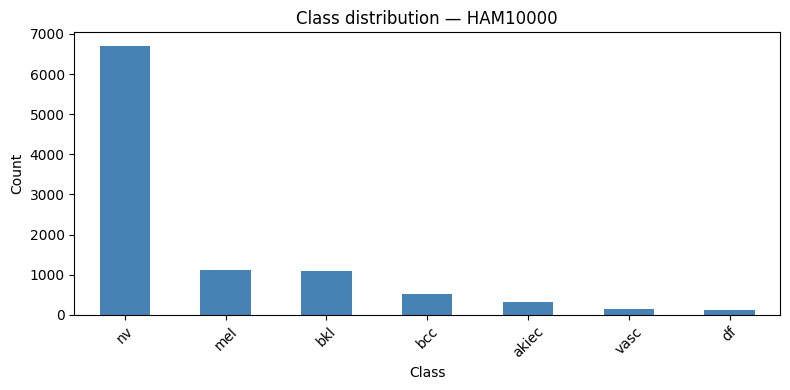

In [4]:
img_paths = {}
for p in glob.glob('data/HAM10000_images_part_*/*.jpg'):
    img_paths[os.path.splitext(os.path.basename(p))[0]] = p

df = pd.read_csv('data/HAM10000_metadata.csv')
df['path'] = df['image_id'].map(img_paths)
df = df.dropna(subset=['path']).reset_index(drop=True)

print(f'Total images: {len(df)}')
print('\nClass distribution:')
print(df['dx'].value_counts())

# Plot distribution
plt.figure(figsize=(8, 4))
df['dx'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Class distribution — HAM10000')
plt.xlabel('Class'); plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# nv dominates at ~67%, df/vasc are <1.5% — severe imbalance

## 4. Handle Class Imbalance

Two things we do:
1. **Oversample minority classes** — duplicate rows so each class has at least 1000 samples
2. **Class weights** — tell the model to penalize mistakes on rare classes more

In [5]:
CLASSES = sorted(df['dx'].unique())
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}
df['label'] = df['dx'].map(CLASS_TO_IDX)

# Oversample: bring every class up to at least 1000 samples
TARGET = 1000
balanced_parts = []
for cls in CLASSES:
    subset = df[df['dx'] == cls]
    if len(subset) < TARGET:
        subset = subset.sample(TARGET, replace=True, random_state=SEED)
    balanced_parts.append(subset)

df_balanced = pd.concat(balanced_parts).sample(frac=1, random_state=SEED).reset_index(drop=True)
print('Balanced class distribution:')
print(df_balanced['dx'].value_counts())

Balanced class distribution:
dx
nv       6705
mel      1113
bkl      1099
akiec    1000
bcc      1000
vasc     1000
df       1000
Name: count, dtype: int64


## 5. Train / Val / Test Split

In [6]:
train_df, test_df = train_test_split(df_balanced, test_size=0.10, stratify=df_balanced['label'], random_state=SEED)
train_df, val_df = train_test_split(train_df, test_size=0.10, stratify=train_df['label'], random_state=SEED)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Train: 10462 | Val: 1163 | Test: 1292


## 6. Data Pipeline

In [7]:
IMG_SIZE = 224
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE

# Augmentation layer — applied only during training
augment = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.1),
])

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    return img, label

def make_dataset(df, training=False):
    ds = tf.data.Dataset.from_tensor_slices((df['path'].values, df['label'].values))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(2000).map(
            lambda x, y: (augment(x, training=True), y),
            num_parallel_calls=AUTOTUNE
        )
    ds = ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)
print('Datasets ready.')

Datasets ready.


## 7. Class Weights

In [8]:
weights = compute_class_weight('balanced', classes=np.arange(len(CLASSES)), y=train_df['label'].values)
class_weight = {i: float(w) for i, w in enumerate(weights)}
print('Class weights:', class_weight)

Class weights: {0: 1.8451499118165784, 1: 1.8451499118165784, 2: 1.6792937399678973, 3: 1.8451499118165784, 4: 1.6569528032942666, 5: 0.2752433570113128, 6: 1.8451499118165784}


## 8. Build Model

EfficientNetB0 pretrained on ImageNet. We freeze the base first, train the head, then unfreeze top layers for fine-tuning.

In [9]:
def build_model():
    base = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(len(CLASSES), activation='softmax')(x)

    return models.Model(inputs, outputs), base

model, base = build_model()
model.summary(line_length=80)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)        │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)       │ (None, 7, 7, 1280)       │     4,049,571 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d          │ (None, 1280)             │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization               │ (None, 1280)             │         5,120 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 1280)             │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 256)              │       327,936 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_1 (Dropout)               │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 7)                │         1,799 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 4,384,426 (16.73 MB)

 Trainable params: 332,295 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## 9. Stage 1 — Train Head Only (base frozen)

In [10]:
model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cbs = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
]

print('Stage 1: training head...')
h1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight,
    callbacks=cbs
)

Stage 1: training head...
Epoch 1/15
327/327 ━━━━━━━━━━━━━━━━━━━━ 256s 639ms/step - accuracy: 0.4907 - loss: 1.6008 - val_accuracy: 0.6191 - val_loss: 0.9616 - learning_rate: 0.0010
Epoch 2/15
327/327 ━━━━━━━━━━━━━━━━━━━━ 206s 552ms/step - accuracy: 0.5779 - loss: 1.1622 - val_accuracy: 0.6664 - val_loss: 0.8667 - learning_rate: 0.0010
Epoch 3/15
327/327 ━━━━━━━━━━━━━━━━━━━━ 185s 536ms/step - accuracy: 0.6016 - loss: 1.0279 - val_accuracy: 0.6853 - val_loss: 0.8316 - learning_rate: 0.0010
Epoch 4/15
327/327 ━━━━━━━━━━━━━━━━━━━━ 189s 547ms/step - accuracy: 0.6193 - loss: 0.9797 - val_accuracy: 0.6690 - val_loss: 0.8103 - learning_rate: 0.0010
Epoch 5/15
327/327 ━━━━━━━━━━━━━━━━━━━━ 197s 533ms/step - accuracy: 0.6245 - loss: 0.9270 - val_accuracy: 0.6965 - val_loss: 0.7425 - learning_rate: 0.0010
Epoch 6/15
327/327 ━━━━━━━━━━━━━━━━━━━━ 186s 539ms/step - accuracy: 0.6325 - loss: 0.9084 - val_accuracy: 0.6586 - val_loss: 0.8342 - learning_rate: 0.0010
Epoch 7/15
327/327 ━━━━━━━━━━━━━━━━━━━

## 10. Stage 2 — Fine-tune Top Layers

In [11]:
# Unfreeze top 40 layers of the base
base.trainable = True
for layer in base.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('Stage 2: fine-tuning...')
h2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight,
    callbacks=cbs
)

Stage 2: fine-tuning...
Epoch 1/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 252s 633ms/step - accuracy: 0.5071 - loss: 1.4703 - val_accuracy: 0.6242 - val_loss: 0.9664 - learning_rate: 1.0000e-05
Epoch 2/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 181s 527ms/step - accuracy: 0.5305 - loss: 1.2646 - val_accuracy: 0.6182 - val_loss: 0.9589 - learning_rate: 1.0000e-05
Epoch 3/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.5334 - loss: 1.2184
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
327/327 ━━━━━━━━━━━━━━━━━━━━ 181s 526ms/step - accuracy: 0.5416 - loss: 1.1814 - val_accuracy: 0.6389 - val_loss: 0.9219 - learning_rate: 1.0000e-05
Epoch 4/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 187s 541ms/step - accuracy: 0.5637 - loss: 1.1221 - val_accuracy: 0.6432 - val_loss: 0.9062 - learning_rate: 5.0000e-06
Epoch 5/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 201s 540ms/step - accuracy: 0.5612 - loss: 1.1072 - val_accuracy: 0.6552 - val_loss: 0.8887 - learning_rate: 5.0000e-06
Epoch 5: early stopping

## 11. Evaluate

41/41 ━━━━━━━━━━━━━━━━━━━━ 19s 466ms/step - accuracy: 0.6277 - loss: 0.9508
Test accuracy: 0.6277

Classification Report:
              precision    recall  f1-score   support

       akiec       0.61      0.44      0.51       100
         bcc       0.64      0.58      0.61       100
         bkl       0.31      0.56      0.40       110
          df       0.73      0.72      0.72       100
         mel       0.25      0.57      0.34       111
          nv       0.92      0.62      0.74       671
        vasc       0.75      0.95      0.84       100

    accuracy                           0.63      1292
   macro avg       0.60      0.63      0.60      1292
weighted avg       0.74      0.63      0.66      1292



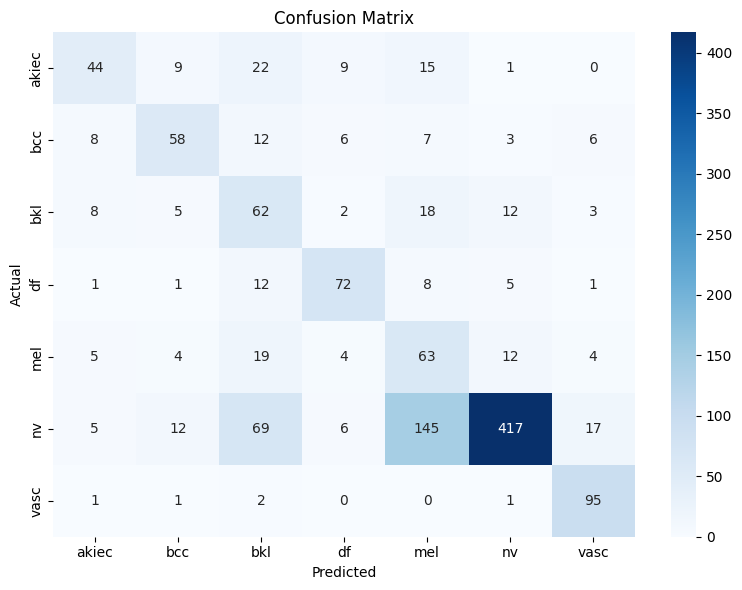

In [12]:
loss, acc = model.evaluate(test_ds)
print(f'Test accuracy: {acc:.4f}')

y_true, y_pred = [], []
for x_batch, y_batch in test_ds:
    preds = model.predict(x_batch, verbose=0)
    y_pred.extend(preds.argmax(axis=1))
    y_true.extend(y_batch.numpy())

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 12. Save & Download

Download both files and place them in your local `skin-ai/models/` folder.

In [13]:
os.makedirs('artifacts', exist_ok=True)
model.save('artifacts/skin_model.keras')

with open('artifacts/classes.json', 'w') as f:
    json.dump({
        'classes': CLASSES,
        'idx_to_class': IDX_TO_CLASS,
        'img_size': IMG_SIZE
    }, f, indent=2)

print('Saved. Downloading...')
from google.colab import files
files.download('artifacts/skin_model.keras')
files.download('artifacts/classes.json')

Saved. Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>